In [6]:
import laspy
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from scipy.stats import zscore
import seaborn as sns
from scipy.spatial import ConvexHull
from scipy.interpolate import griddata

In [2]:
# Load a .laz file
file_path = "CASBC_0033_20240912_1.laz"
las = laspy.read(file_path)

dimensions = list(las.point_format.dimension_names)
print("Available Dimensions:", dimensions)
print("Point Format:", las.header.point_format)
print("Number of Points:", las.header.point_count)

Available Dimensions: ['X', 'Y', 'Z', 'intensity', 'return_number', 'number_of_returns', 'synthetic', 'key_point', 'withheld', 'overlap', 'scanner_channel', 'scan_direction_flag', 'edge_of_flight_line', 'classification', 'user_data', 'scan_angle', 'point_source_id', 'gps_time', 'red', 'green', 'blue']
Point Format: <PointFormat(7, 0 bytes of extra dims)>
Number of Points: 10562656


In [3]:
# Convert ScaledArrayView to NumPy arrays
x = np.array(las.x)
y = np.array(las.y)
z = np.array(las.z)

# Convert to DataFrame
df = pd.DataFrame({
    "X": x,
    "Y": y,
    "Z": z,
    "intensity": las.intensity,
    "return_number": las.return_number,
    "number_of_returns": las.number_of_returns,
    "synthetic": las.synthetic,
    "key_point": las.key_point,
    "withheld": las.withheld,
    "overlap": las.overlap,
    "scanner_channel": las.scanner_channel,
    "scan_direction_flag": las.scan_direction_flag,
    "edge_of_flight_line": las.edge_of_flight_line,
    "classification": las.classification,
    "user_data": las.user_data,
    "scan_angle": las.scan_angle,
    "point_source_id": las.point_source_id,
    "gps_time": las.gps_time,
    "red": las.red,
    "green": las.green,
    "blue": las.blue
})

# Basic information
print('Dataset Shape:', df.shape)
df.info()

Dataset Shape: (10562656, 21)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10562656 entries, 0 to 10562655
Data columns (total 21 columns):
 #   Column               Dtype  
---  ------               -----  
 0   X                    float64
 1   Y                    float64
 2   Z                    float64
 3   intensity            uint16 
 4   return_number        object 
 5   number_of_returns    object 
 6   synthetic            object 
 7   key_point            object 
 8   withheld             object 
 9   overlap              object 
 10  scanner_channel      object 
 11  scan_direction_flag  object 
 12  edge_of_flight_line  object 
 13  classification       uint8  
 14  user_data            uint8  
 15  scan_angle           int16  
 16  point_source_id      uint16 
 17  gps_time             float64
 18  red                  uint16 
 19  green                uint16 
 20  blue                 uint16 
dtypes: float64(4), int16(1), object(9), uint16(5), uint8(2)
memory usage

In [4]:
df.head()

,X,Y,Z,intensity,return_number,number_of_returns,synthetic,key_point,withheld,overlap,...,scan_direction_flag,edge_of_flight_line,classification,user_data,scan_angle,point_source_id,gps_time,red,green,blue
0,4.256332,-0.007701,-1.641088,0,"[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",...,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",0,0,0,0,0.0,40704,32512,33792
1,4.259612,-0.007666,-1.636745,0,"[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",...,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",0,0,0,0,0.0,41984,33792,35072
2,4.284598,-0.007614,-1.640710,0,"[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",...,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",0,0,0,0,0.0,47616,39424,40704
3,4.371070,-0.007484,-1.662340,0,"[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",...,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",0,0,0,0,0.0,43008,34816,36096
4,4.543912,-0.007537,-1.716308,0,"[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",...,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...",0,0,0,0,0.0,50432,42240,43520


In [5]:
# Check for Missing Values
print('Missing Value:')  
df.isnull().sum()

Missing Value:


X                      0
Y                      0
Z                      0
intensity              0
return_number          0
number_of_returns      0
synthetic              0
key_point              0
withheld               0
overlap                0
scanner_channel        0
scan_direction_flag    0
edge_of_flight_line    0
classification         0
user_data              0
scan_angle             0
point_source_id        0
gps_time               0
red                    0
green                  0
blue                   0
dtype: int64

In [6]:
# Summary statistics
df.describe()

,X,Y,Z,intensity,classification,user_data,scan_angle,point_source_id,gps_time,red,green,blue
count,1.056266e+07,1.056266e+07,1.056266e+07,1.056266e+07,10562656.0,10562656.0,10562656.0,10562656.0,10562656.0,1.056266e+07,1.056266e+07,1.056266e+07
mean,-3.653952e-02,-2.049277e-01,1.302587e+00,7.573853e-07,0.0,0.0,0.0,0.0,0.0,2.935705e+04,2.877243e+04,2.996936e+04
std,4.441043e+00,4.925220e+00,3.171627e+00,8.702786e-04,0.0,0.0,0.0,0.0,0.0,1.633204e+04,1.608685e+04,1.604533e+04
min,-5.189875e+01,-4.919752e+01,-6.778975e+00,0.000000e+00,0.0,0.0,0.0,0.0,0.0,0.000000e+00,0.000000e+00,0.000000e+00
25%,-1.289814e+00,-1.206806e+00,-1.373740e+00,0.000000e+00,0.0,0.0,0.0,0.0,0.0,1.689600e+04,1.638400e+04,1.740800e+04
50%,1.740400e-03,4.197445e-02,1.003392e+00,0.000000e+00,0.0,0.0,0.0,0.0,0.0,2.508800e+04,2.432000e+04,2.560000e+04
75%,1.421099e+00,1.208657e+00,2.630504e+00,0.000000e+00,0.0,0.0,0.0,0.0,0.0,3.840000e+04,3.686400e+04,3.865600e+04
max,5.306548e+01,5.240013e+01,2.222659e+01,1.000000e+00,0.0,0.0,0.0,0.0,0.0,6.528000e+04,6.528000e+04,6.528000e+04


In [7]:
x_range = (df["X"].min(), df["X"].max())
y_range = (df["Y"].min(), df["Y"].max())
z_range = (df["Z"].min(), df["Z"].max())

print("X Range:", x_range)
print("Y Range:", y_range)
print("Z Range:", z_range)


X Range: (-51.8987464, 53.065483)
Y Range: (-49.197525, 52.400127399999995)
Z Range: (-6.778975, 22.2265892)


In [9]:
point_density = len(df) / ((x_range[1] - x_range[0]) * (y_range[1] - y_range[0]))
print("Point Density:", point_density, "points per square unit")

Point Density: 990.485544072869 points per square unit


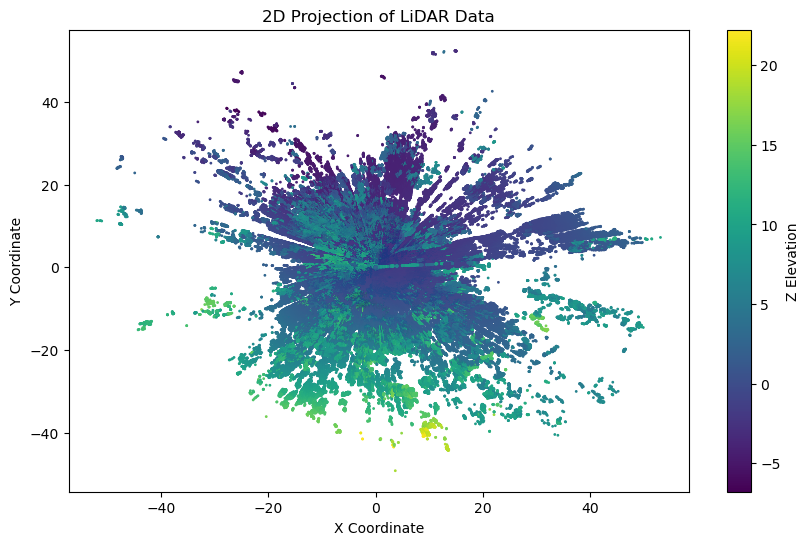

In [10]:
plt.figure(figsize=(10, 6))
plt.scatter(df["X"], df["Y"], c=df["Z"], cmap="viridis", s=1)
plt.xlabel("X Coordinate")
plt.ylabel("Y Coordinate")
plt.title("2D Projection of LiDAR Data")
plt.colorbar(label="Z Elevation")
plt.show()

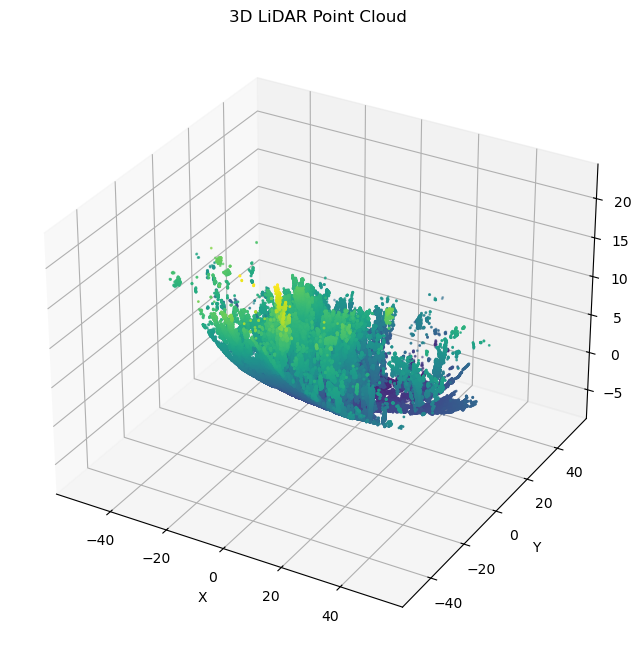

In [11]:
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection="3d")
ax.scatter(df["X"], df["Y"], df["Z"], c=df["Z"], cmap="viridis", s=1)
ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")
ax.set_title("3D LiDAR Point Cloud")
plt.show()

/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


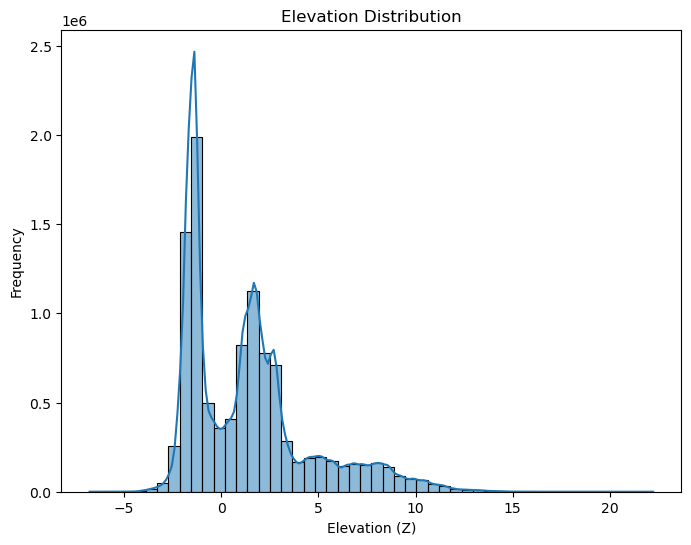

In [12]:
plt.figure(figsize=(8, 6))
sns.histplot(df["Z"], bins=50, kde=True)
plt.xlabel("Elevation (Z)")
plt.ylabel("Frequency")
plt.title("Elevation Distribution")
plt.show()

/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


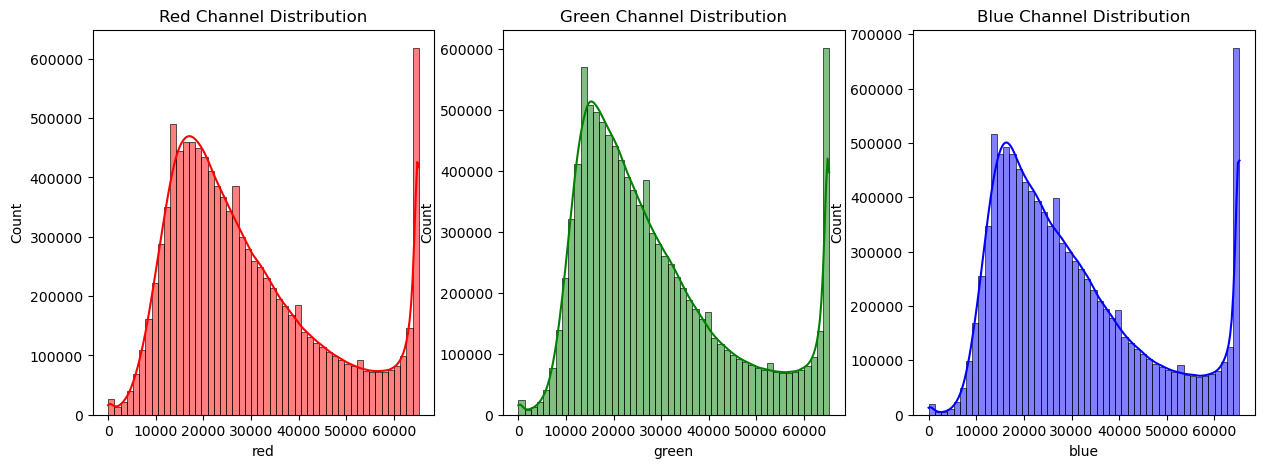

In [14]:
fig, axs = plt.subplots(1, 3, figsize=(15, 5))
sns.histplot(df["red"], bins=50, kde=True, ax=axs[0], color="red")
sns.histplot(df["green"], bins=50, kde=True, ax=axs[1], color="green")
sns.histplot(df["blue"], bins=50, kde=True, ax=axs[2], color="blue")
axs[0].set_title("Red Channel Distribution")
axs[1].set_title("Green Channel Distribution")
axs[2].set_title("Blue Channel Distribution")
plt.show()


/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


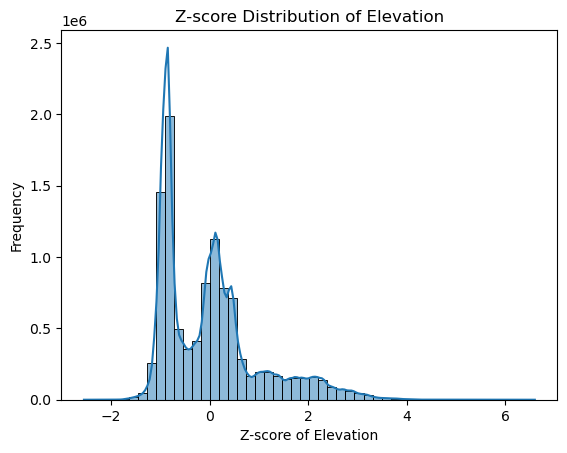

In [15]:
df["Z_zscore"] = (df["Z"] - np.mean(df["Z"])) / np.std(df["Z"])
sns.histplot(df["Z_zscore"], bins=50, kde=True)
plt.xlabel("Z-score of Elevation")
plt.ylabel("Frequency")
plt.title("Z-score Distribution of Elevation")
plt.show()

Number of outliers: 102739


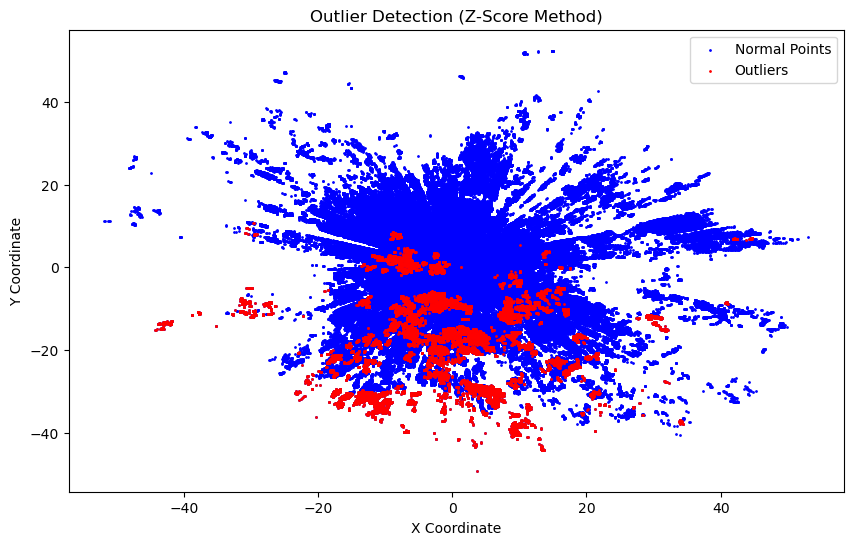

In [16]:
df["Z_zscore"] = zscore(df["Z"])
outliers = df[df["Z_zscore"].abs() > 3]  # Filter outliers
print(f"Number of outliers: {len(outliers)}")

plt.figure(figsize=(10, 6))
plt.scatter(df["X"], df["Y"], c="blue", s=1, label="Normal Points")
plt.scatter(outliers["X"], outliers["Y"], c="red", s=1, label="Outliers")
plt.xlabel("X Coordinate")
plt.ylabel("Y Coordinate")
plt.title("Outlier Detection (Z-Score Method)")
plt.legend()
plt.show()

Load dataset and get brief information about it.

In [ ]:
# Terrestrial LiDAR dataset #2
lidar_file = "CASBC_0055_20241117_1.laz"
pointcloud_data = laspy.read(lidar_file)

In [ ]:
# Information about LiDAR data
print("Point Format:", pointcloud_data.header.point_format)
print("Number of Points:", pointcloud_data.header.point_count)

Point Format: <PointFormat(7, 0 bytes of extra dims)>
Number of Points: 8722346


Extract attributes from LiDAR data.

In [ ]:
x = np.array(pointcloud_data.x)
y = np.array(pointcloud_data.y)
z = np.array(pointcloud_data.z)

intensity = np.array(pointcloud_data.intensity)
classification = np.array(pointcloud_data.classification)
return_number = np.array(pointcloud_data.return_number)

Create dataframe with information extracted.

In [ ]:
pointcloud_df = pd.DataFrame({'x': x, 'y': y, 'z': z, 
                   'intensity': intensity, 
                   'classification': classification, 
                   'return_number': return_number})

Use describe() to have a brief overview of min/max values, mean, standard deviation to better understand the data, detect outliers, and data quality issues.

In [ ]:
print(pointcloud_df.describe())

                  x             y             z     intensity  classification  \
count  8.722346e+06  8.722346e+06  8.722346e+06  8.722346e+06       8722346.0   
mean   1.067590e-01  5.523705e-01  1.629174e+00  1.146481e-07             0.0   
std    7.388311e+00  7.178418e+00  3.842939e+00  3.385972e-04             0.0   
min   -5.429742e+01 -5.055194e+01 -5.314794e+00  0.000000e+00             0.0   
25%   -2.322853e+00 -1.662753e+00 -1.520746e+00  0.000000e+00             0.0   
50%   -1.812074e-01 -8.697090e-02 -7.972654e-01  0.000000e+00             0.0   
75%    1.416873e+00  1.520325e+00  5.100681e+00  0.000000e+00             0.0   
max    5.358553e+01  5.346376e+01  2.078632e+01  1.000000e+00             0.0   

       return_number  
count      8722346.0  
mean             1.0  
std              0.0  
min              1.0  
25%              1.0  
50%              1.0  
75%              1.0  
max              1.0  


Check for missing values to adjust accordingly if necessary. There are none.

In [ ]:
print(pointcloud_df.isnull().sum())

x                 0
y                 0
z                 0
intensity         0
classification    0
return_number     0
dtype: int64


Plot classification to see the different objects present to separate the terrain. Check value count for exact count for each code.

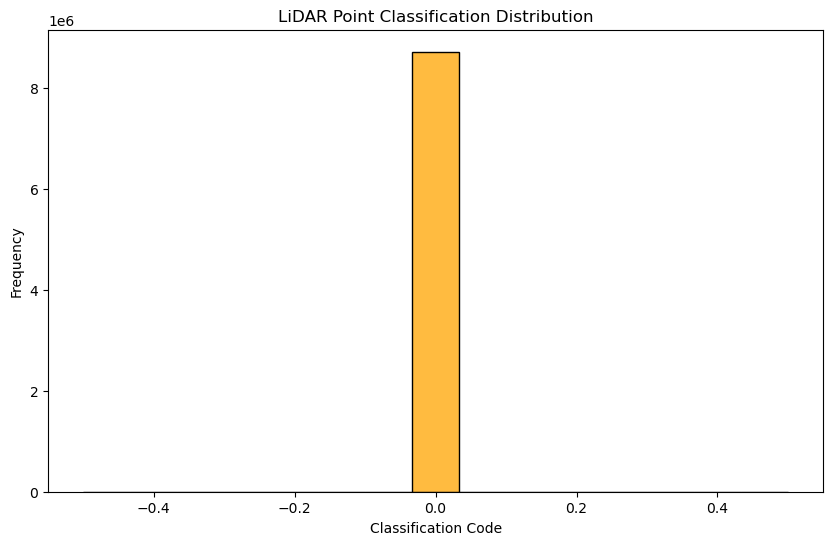

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(pointcloud_df["classification"], bins=15, kde=False, color='orange')
plt.title("LiDAR Point Classification Distribution")
plt.xlabel("Classification Code")
plt.ylabel("Frequency")
plt.show()

In [ ]:
pointcloud_df["classification"].value_counts()

classification
0    8722346
Name: count, dtype: int64

Complete return number analysis to identify each classification of object and different surfaces.

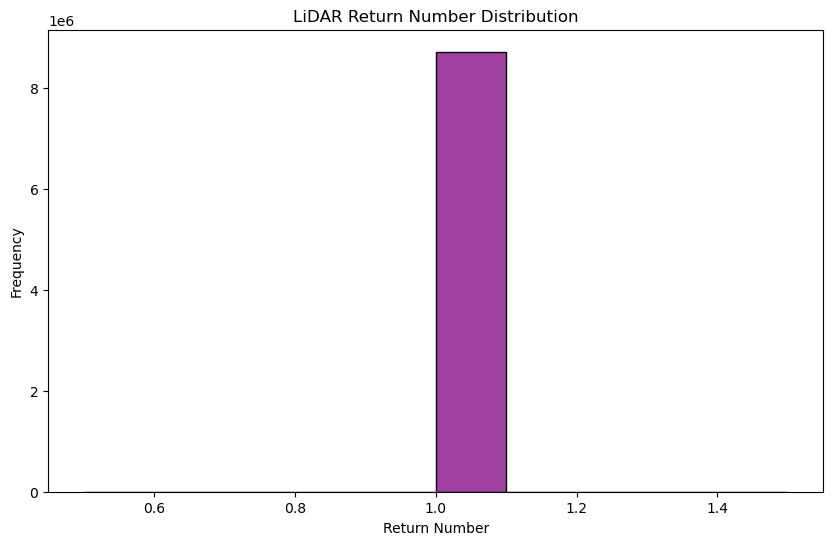

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(pointcloud_df["return_number"], bins=10, kde=False, color='purple')
plt.title("LiDAR Return Number Distribution")
plt.xlabel("Return Number")
plt.ylabel("Frequency")
plt.show()

View the 2D spatial coverage of the LiDAR dataset with the elevation encoded.

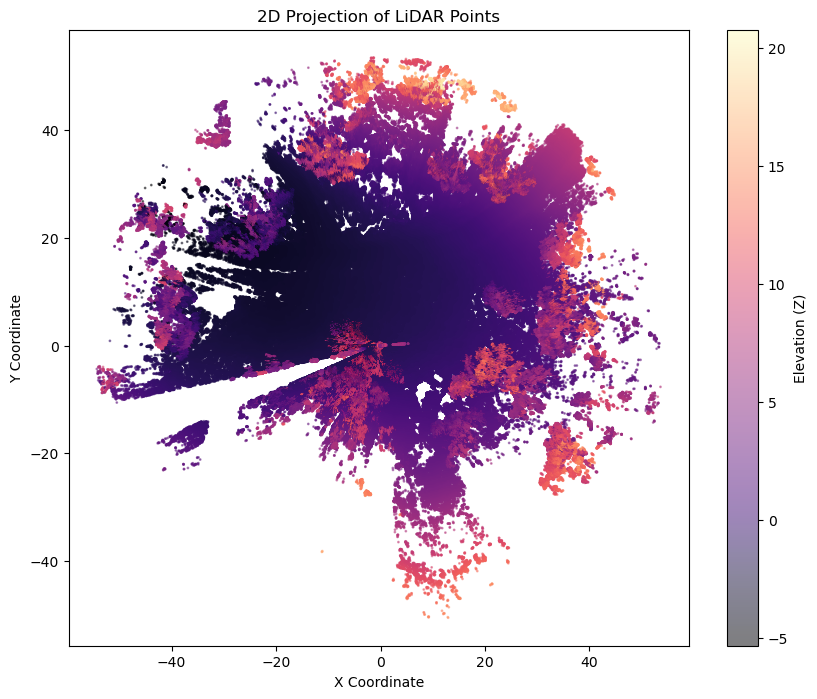

In [ ]:
plt.figure(figsize=(10, 8))
plt.scatter(pointcloud_df["x"], pointcloud_df["y"], s=1, alpha=0.5, c=pointcloud_df["z"], cmap="magma")
plt.colorbar(label="Elevation (Z)")
plt.xlabel("X Coordinate")
plt.ylabel("Y Coordinate")
plt.title("2D Projection of LiDAR Points")
plt.show()

Here is the heatmap of the density of the given points for clarity of terrain distribution.

Elevation histogram to show the terrain variation and different surface layers.

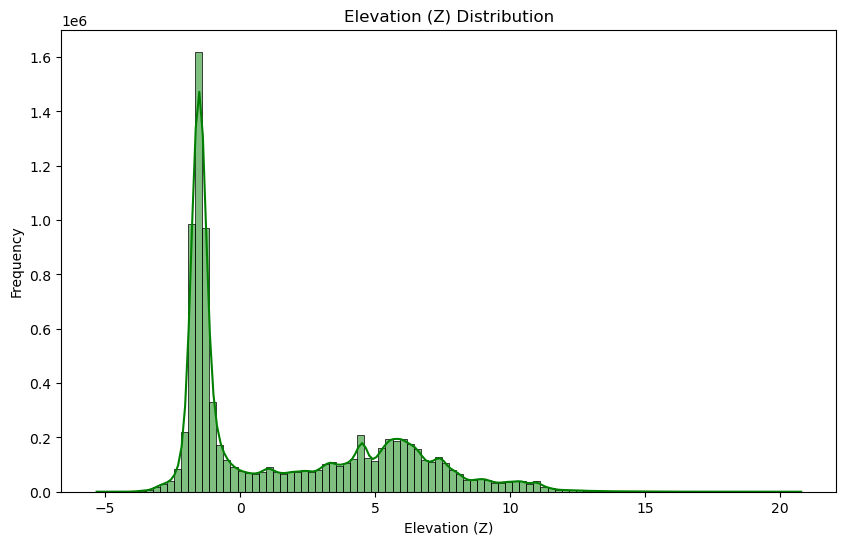

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(pointcloud_df["z"], bins=100, kde=True, color='green')
plt.title("Elevation (Z) Distribution")
plt.xlabel("Elevation (Z)")
plt.ylabel("Frequency")
plt.show()

View side profile of terrain to see distinguish different greenery.

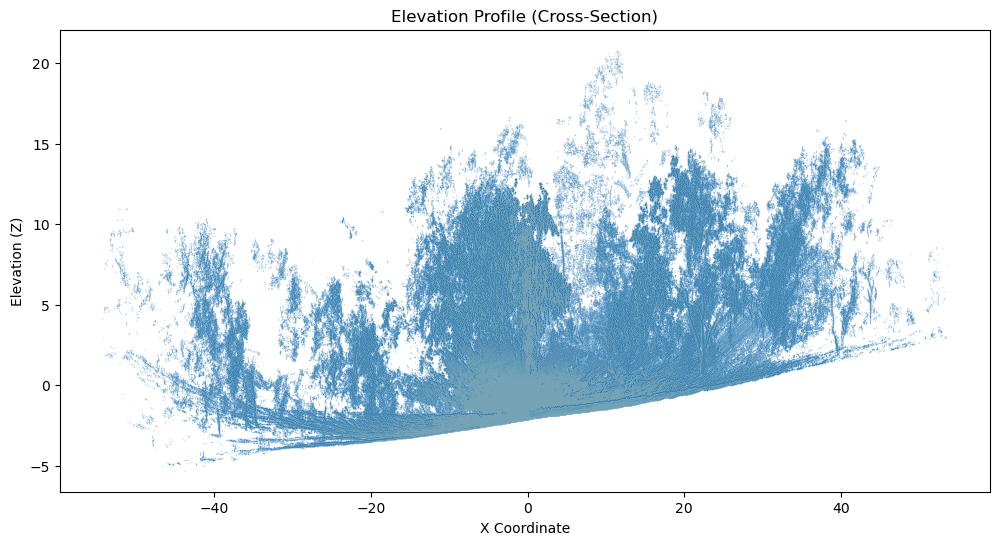

In [ ]:
plt.figure(figsize=(12, 6))
sns.scatterplot(x=pointcloud_df["x"], y=pointcloud_df["z"], alpha=0.2, s=1)
plt.title("Elevation Profile (Cross-Section)")
plt.xlabel("X Coordinate")
plt.ylabel("Elevation (Z)")
plt.show()

Gives a full perspective view of the LiDAR scan.

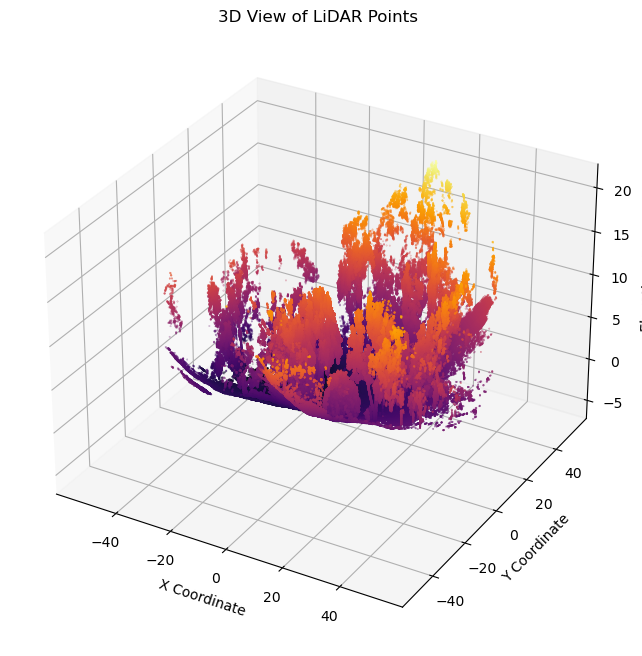

In [ ]:
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(pointcloud_df["x"], pointcloud_df["y"], pointcloud_df["z"], c=pointcloud_df["z"], cmap='inferno', s=0.1)
ax.set_xlabel("X Coordinate")
ax.set_ylabel("Y Coordinate")
ax.set_zlabel("Elevation (Z)")
plt.title("3D View of LiDAR Points")
plt.show()

### Read the Terrestrial LiDAR Data

In [ ]:
# Terrestrial Dataset #3
laz_file_path = 'CASBC_0001_20240910_1.laz'

# Open the .laz file using laspy
with laspy.open(laz_file_path) as las:
    # Read the point data
    point_cloud = las.read()
    
# Convert point cloud to numpy arrays
x = np.array(point_cloud.x)
y = np.array(point_cloud.y)
z = np.array(point_cloud.z)

# print some basic information about the file
print(f"Number of points: {len(x)}")
print(f"File header information: {las.header}")

Number of points: 5043294
File header information: <LasHeader(1.4, <PointFormat(7, 0 bytes of extra dims)>)>


### Calculate Basic EDA Features

          x         y         z
0  0.887801  0.006639 -1.530114
1  0.894944  0.006659 -1.538397
2  0.865284  0.006496 -1.482763
3  0.858373  0.006446 -1.466822
4  0.862717  0.006452 -1.470362
Basic Statistics:
                  x             y             z
count  5.043294e+06  5.043294e+06  5.043294e+06
mean  -5.486926e-01  9.176233e-01 -6.761326e-01
std    5.400602e+00  4.743485e+00  1.876663e+00
min   -5.195738e+01 -2.616413e+01 -1.151015e+01
25%   -1.146212e+00 -9.174836e-01 -1.312179e+00
50%   -5.750790e-02 -5.041145e-02 -7.455369e-01
75%    1.205557e+00  1.687909e+00 -1.938032e-01
max    5.291031e+01  5.356737e+01  2.679758e+01


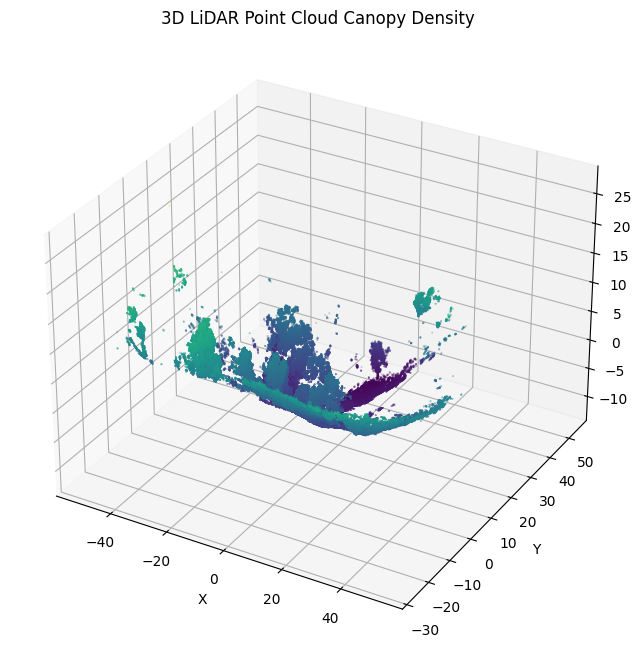

Point Density (points per square unit area): 603.17


In [ ]:
# Convert LiDAR data into a Pandas DataFrame for easier exploration
# Create a DataFrame from the LiDAR point cloud data
df = pd.DataFrame({'x': x.tolist(), 'y': y.tolist(), 'z': z.tolist()})

# Verify the DataFrame is correctly created
print(df.head())

# Basic descriptive statistics
print("Basic Statistics:")
print(df.describe())

# Plot the 3D point cloud distribution
fig = plt.figure(figsize=(12, 8))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(x, y, z, s=0.1, c=z, cmap='viridis')
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
plt.title('3D LiDAR Point Cloud Canopy Density')
plt.show()

# Calculate point density
point_density = len(x) / (np.ptp(x) * np.ptp(y))  # Point density = points per unit area
print(f"Point Density (points per square unit area): {point_density:.2f}")

### Canopy Height Model (CHM) and Vegetation Analysis

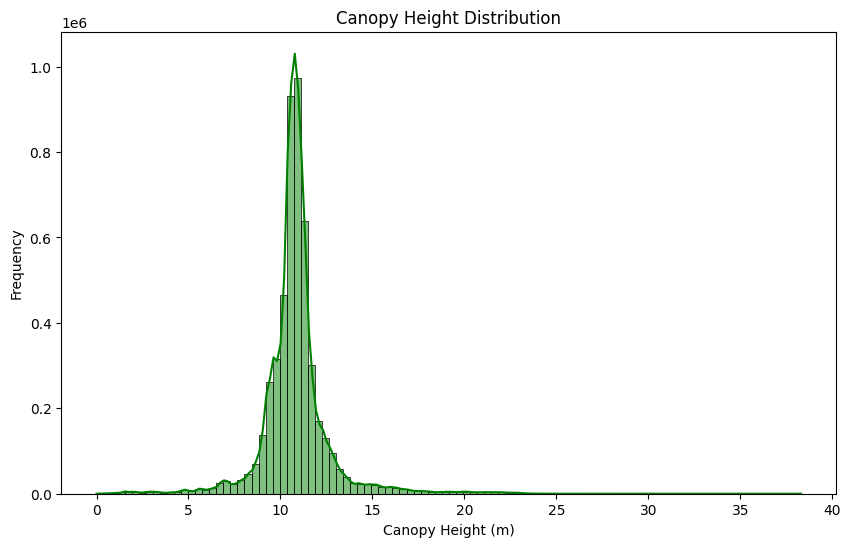

In [ ]:
# Ground points are typically the lowest Z values, you can define a threshold or use a statistical approach
ground_threshold = np.percentile(z, 10)  # For simplicity, using 10th percentile as ground threshold
ground_points = z[z <= ground_threshold]

# Calculate the canopy height by subtracting ground elevation from overall point heights
canopy_height = z - np.min(ground_points)

# Visualize Canopy Height Distribution
plt.figure(figsize=(10, 6))
sns.histplot(canopy_height, bins=100, color='green', kde=True)
plt.title('Canopy Height Distribution')
plt.xlabel('Canopy Height (m)')
plt.ylabel('Frequency')
plt.show()

### Terrain Slope Analysis

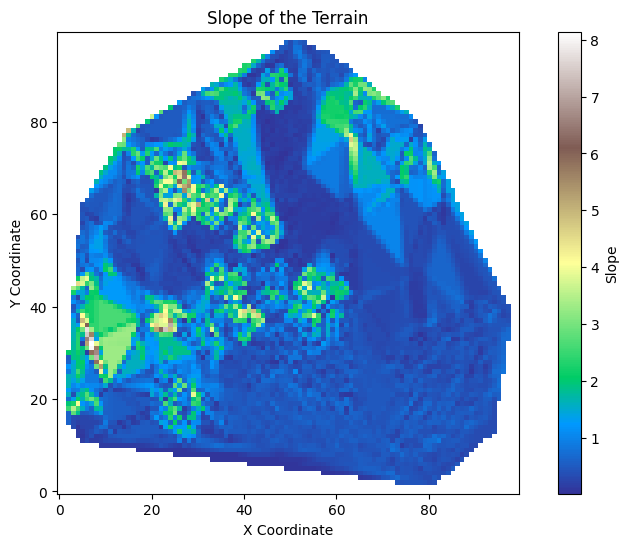

In [ ]:
#Define the grid resolution (assuming x and y are uniformly spaced in a region)
grid_x, grid_y = np.meshgrid(np.linspace(np.min(x), np.max(x), 100), np.linspace(np.min(y), np.max(y), 100))

# Interpolate the z-values (elevation) onto this grid
grid_z = griddata((x, y), z, (grid_x, grid_y), method='linear')

# Calculate slope (gradient) using numpy's gradient function
dx, dy = np.gradient(grid_z, axis=(1, 0))  # Calculate gradients in x and y direction

# Calculate the slope (magnitude of the gradient)
slope = np.sqrt(dx**2 + dy**2)

# Visualize the slope
plt.figure(figsize=(10, 6))
plt.imshow(slope, cmap='terrain', origin='lower')
plt.colorbar(label='Slope')
plt.title('Slope of the Terrain')
plt.xlabel('X Coordinate')
plt.ylabel('Y Coordinate')
plt.show()

### Canopy Density and Vegetation Structure

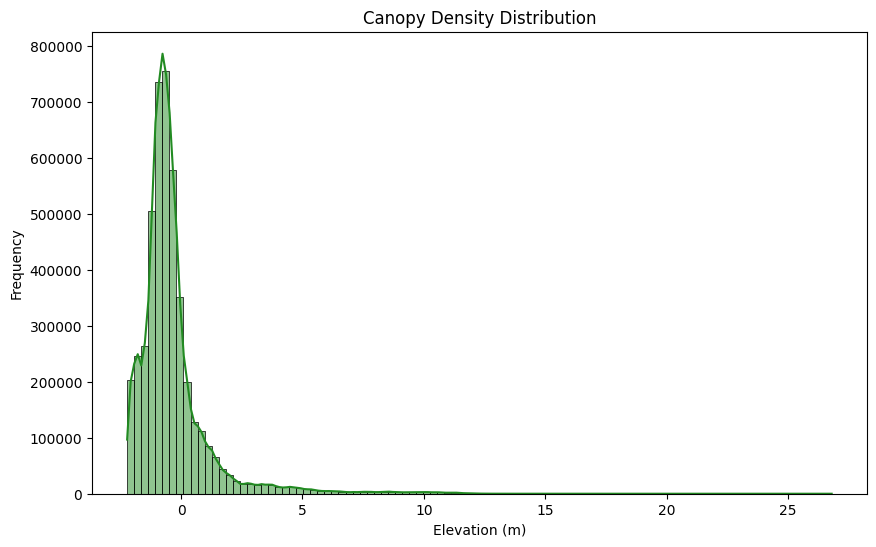

In [ ]:
# Canopy density can be analyzed by filtering out ground points
canopy_points = z[z > ground_threshold]

# Visualize the density of canopy points
plt.figure(figsize=(10, 6))
sns.histplot(canopy_points, bins=100, color='forestgreen', kde=True)
plt.title('Canopy Density Distribution')
plt.xlabel('Elevation (m)')
plt.ylabel('Frequency')
plt.show()